In [13]:
from manim import *

In [60]:
%%manim -v WARNING -qm LimitOfXOverX


class LimitOfXOverX(Scene):
    def construct(self):
        # Axes setup
        axes = Axes(
            x_range=[-4, 4, 1],
            y_range=[0, 2, 0.5],
            x_length=8,
            y_length=4,
            axis_config={"include_tip": True}
        )

        # Function: f(x) = x/x (excluding 0)
        def x_over_x(x):
            return 1 if x != 0 else None

        # Plot excluding x=0
        graph = axes.plot(lambda x: x_over_x(x), color=BLUE, x_range=[-4, -0.1])
        graph2 = axes.plot(lambda x: x_over_x(x), color=BLUE, x_range=[0.1, 4])

        # Hole at x=0
        hole = Dot(axes.c2p(0, 1), color=RED)

        # Labels and titles
        title = Text("Limit of f(x) = x/x as x → 0", font_size=36).to_edge(UP)
        func_label = MathTex(r"f(x) = \frac{x}{x}, \quad x \ne 0").next_to(graph2, UP)
        limit_text = MathTex(r"\lim_{x \to 0} \frac{x}{x} = 1").to_edge(DOWN)

        # Build the animation
        self.play(Write(title))
        self.play(Create(axes))
        self.play(Create(graph), Create(graph2))
        self.play(FadeIn(hole), run_time=1)
        self.play(Write(func_label))
        self.wait(1)

        # Emphasize the hole
        self.play(hole.animate.scale(1.5).set_color(YELLOW))
        self.wait(1)

        # Show the limit conclusion
        self.play(Write(limit_text))
        self.wait(2)



(process:1762): GLib-GObject-WARNING **: 13:52:05.381: cannot unreference class of invalid (unclassed) type '(NULL)'


[10/12/25 21:14:21] WARNING  --save_as_gif is deprecated, please use --format=gif instead!           ]8;id=972662;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py\commands.py]8;;\:]8;id=984743;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py#50\50]8;;\

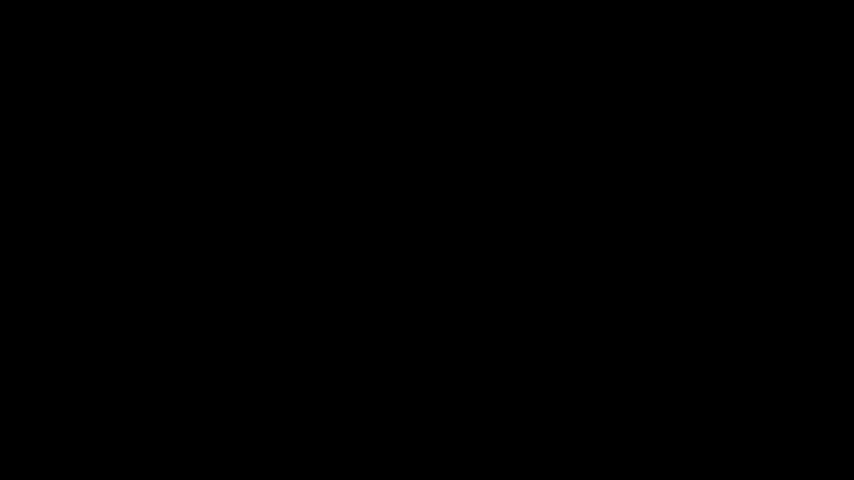

In [ ]:
%%manim -v WARNING -ql -i CurveSketching

class CurveSketching(Scene):
    def construct(self):
        # Divide the screen visually: left for text, right for graph
        left_text_area = Rectangle(width=5.5, height=7, color=GREY, fill_opacity=0).to_edge(LEFT)
        right_graph_area = Rectangle(width=5.5, height=7, color=GREY, fill_opacity=0).to_edge(RIGHT)
        # Uncomment next lines if you want to see the separation visually
        # self.add(left_text_area, right_graph_area)

        # Axes for y = x^2 graph (shifted to the right)
        axes = Axes(
            x_range=[-5, 5, 1],
            y_range=[-5, 5, 1],
            x_length=5,
            y_length=5,
            axis_config={"color": WHITE},
            tips=False
        ).to_edge(RIGHT).shift(LEFT * 0.5)
############################################################################################################################################################################################


        # Define the function y = x^2
        graph = axes.plot(lambda x: x**2, color=YELLOW)
        graph_label = axes.get_graph_label(graph, label="y = x^2", x_val=2.2, direction=UR)

        graph_copy1 = graph.copy().set_color(YELLOW)

        # STEP 1: Title and introduction text
        step1 = Text("Step 1: Understand the function", font_size=25, color=BLUE).to_edge(LEFT).shift(UP * 2)
        expl1 = Text("The function y = x² is of degree two \nso it represents a parabola", font_size=28).next_to(step1, DOWN, aligned_edge=LEFT)

        self.play(Write(step1))
        self.play(Write(expl1))
        self.wait(2)

        # Draw axes show graph of parabola could be among these.
        step2 = Text("parabola could be among these", font_size=28).next_to(expl1, DOWN, buff=0.8, aligned_edge=LEFT)
        self.play(Write(step2))
        self.play(Create(axes))
        self.play(Create(graph), run_time=3)
        self.play(Write(graph_label))

        # Shift the curve right by 1 unit and up by 2 units within the axes coordinate system
        shift_vector = axes.c2p(1, 2) - axes.c2p(0, 0)
        self.play(graph_copy1.animate.shift(shift_vector))
        # Change the original parabola color to grey
        self.play(graph.animate.set_color(GREY))
        
       

        shift_vector = axes.c2p(-3, -4) - axes.c2p(1, 2)
        graph_copy2 = graph_copy1.copy().set_color(YELLOW)
        self.play(graph_copy2.animate.shift(shift_vector))
        self.play(graph_copy1.animate.set_color(GREY))

        shift_vector = axes.c2p(-3, 5) - axes.c2p(-3, -4)
        graph_copy3 = graph_copy2.copy().set_color(YELLOW)
        self.play(graph_copy3.animate.shift(shift_vector))
        self.play(graph_copy2.animate.set_color(GREY))

        shift_vector = axes.c2p(2, -2) - axes.c2p(-3, 5)
        graph_copy4 = graph_copy3.copy().set_color(YELLOW)
        self.play(graph_copy4.animate.shift(shift_vector))
        self.play(graph_copy3.animate.set_color(GREY))

   

        # Stretch horizontally(making wider) and rotate around point (2,-2)
        self.play(graph_copy4.animate.stretch(2, dim=0))  # dim=0 means x-direction
        self.play(graph_copy4.animate.rotate(PI, about_point=axes.c2p(2,-2)), run_time=3)

        shift_vector = axes.c2p(0, 0) - axes.c2p(2, -2)
        self.play(graph_copy4.animate.shift(shift_vector))



        # Rotate around the origin of the AXES (not the screen)
        self.play(graph_copy4.animate.rotate(PI/2, about_point=axes.c2p(0, 0)), run_time=2)

        # Vertical line at x = 2, extend far above and below
        x_val = 2
        vertical_line = Line(
            start=axes.c2p(x_val, -1000),  # very low y
            end=axes.c2p(x_val, 1000),     # very high y
            color=BLUE
        )


        # Draw the vertical line
        self.play(Create(vertical_line))
        tex1 = Text("Definitely this can't be\n as it doesnot satisfy vertical line test", font_size=28).next_to(step2, DOWN, buff=0.8, aligned_edge=LEFT)
        self.play(Write(tex1))
        self.wait(1)
# #################################################################################################################################################################################################
        #Fade out every text up to now
        self.play(FadeOut(step1), FadeOut(expl1), FadeOut(step2) ,FadeOut(tex1))
        self.wait(1)


        tex2 = Text("First we do origin test", font_size=25, color=BLUE).to_edge(LEFT).shift(UP * 2)
        self.play(Write(tex2))
        self.wait(1)

        
        # Math equatiions for origin test
        eqs = [
            "f(x) = 0",
            "\\text{at } x = 0 \\Rightarrow f(0) = 0^2 = 0",
            "\\text{so the curve passes} \\\\ \\text{through the origin (0,0)}"
        ]

        m_eqs = [MathTex(e) for e in eqs]
        m_eqs[0].next_to(tex2, DOWN, buff=0.6, aligned_edge=LEFT)
        for i, eq in enumerate(m_eqs):
            if i > 0:
                eq.next_to(m_eqs[i-1], DOWN, buff=0.6, aligned_edge=LEFT)
            self.play(Write(eq))
            self.wait(0.5)

        #Fade out every text up to now
        self.play(FadeOut(tex2))
        for eq in m_eqs:
            self.play(FadeOut(eq))
        self.wait(1)

        tex3 = Text("Now we remove the curve\n that doesnot pass origin test\n and vertical line test", font_size=25, color=BLUE).to_edge(LEFT).shift(UP * 2)
        self.play(Write(tex3))  
        self.play(FadeOut(graph_copy1), FadeOut(graph_copy2),FadeOut(graph_copy3),FadeOut(graph_copy4),FadeOut(vertical_line))
        self.play(graph.animate.set_color(YELLOW))
        tex4 = Text("So the curves of f(x) = x^2 \ncould be among these  ", font_size=28).next_to(tex3, DOWN, buff=0.8, aligned_edge=LEFT)
        self.play(Write(tex4))

        graph_copy11 = graph.copy().set_color(BLUE)
        self.play(graph_copy11.animate.rotate(PI, about_point=axes.c2p(0, 0)), run_time=2)

        self.play(FadeOut(tex3), FadeOut(tex4))

        

        self.wait(2)


        
        
        

    # STEP 3: Plot some key points
        line1 = MathTex("\\text{Compairing } y = x^2 with,y = ax^2 + bx + c", font_size=30)
        self.play(Write(line1.to_edge(LEFT).shift(UP * 2)))
        line2 = MathTex("\\text{We get, a = 1, b = 0, c = 0}", font_size=30)
        self.play(Write(line2.next_to(line1, DOWN, buff=0.6, aligned_edge=LEFT)))
        expl3 = MathTex("\\text{Since $a > 0$, the parabola opens upwards}", font_size=30).next_to(line2, DOWN, buff=0.8, aligned_edge=LEFT)
        self.play(Write(expl3))

        self.wait(2)

        self.play(FadeOut(line1), FadeOut(line2), FadeOut(expl3))
        self.wait(1)
        expl4 = MathTex("\\text{This graph looks like\n the only possible option }", font_size=30).to_edge(LEFT).shift(UP * 2)
        self.play(Write(expl4))
        self.play(FadeOut(graph_copy11))


        line3 = MathTex("\\text{For Vertex, x =-b/2a = 0, y = 0,vertex = (0,0)}", font_size=30)
        self.play(Write(line3.next_to(expl4, DOWN, buff=0.6, aligned_edge=LEFT)))
        line4 = MathTex("\\text{For Domain = (-inf, +inf), Range = [0,+inf]}", font_size=30).next_to(line3, DOWN, buff=0.6, aligned_edge=LEFT)
        self.play(Write(line4))
        self.wait(1)

        self.play(FadeOut(expl4), FadeOut(line3), FadeOut(line4))
        self.wait(1)
        line5 = MathTex("\\text{It is not clear why not Streach and squezze!!!}", font_size=30).to_edge(LEFT).shift(UP * 2)
        self.play(Write(line5))
        self.wait(1)

        self.play(graph.animate.stretch(2, dim=0))
        self.play(graph.animate.stretch(0.2, dim=0))
        self.FadeOut(line5)
        self.wait(2)

        # Table data (x, y = x^2)

        data = [
            ["x", "y = x^2"],
            ["-2", "4"],
            ["-1", "1"],
            ["0", "0"],
            ["1", "1"],
            ["2", "4"]
        ]

        # Create the table
        table = Table(
            data,
            include_outer_lines=True,
            line_config={"color": WHITE},
            element_to_mobject=lambda e: MathTex(e)  # Math mode for proper rendering
        )


        # Scale and move to left half
        table.scale(0.8)
        table.to_edge(LEFT)  # Move entire table to the left side

        # Animate table creation
        self.play(Create(table))
        self.wait(2)

        

        # # Mark key points on the curve
        # points = [axes.coords_to_point(x, x**2) for x in [-2, -1, 0, 1, 2]]
        # dots = VGroup(*[Dot(p, color=RED) for p in points])
        # self.play(LaggedStart(*[GrowFromCenter(dot) for dot in dots], lag_ratio=0.2))
        # self.wait(1)








        # # STEP 4: Connect the dots with a smooth curve
        # step4 = Text("Step 4: Connect the points smoothly", font_size=32, color=BLUE).next_to(expl3, DOWN, buff=0.8, aligned_edge=LEFT)
        # self.play(Write(step4))
        # self.play(Create(graph), run_time=3)
        # self.wait(1)

        # # STEP 5: Label the curve
        # step5 = Text("Step 5: Label your graph", font_size=32, color=BLUE).next_to(step4, DOWN, buff=0.8, aligned_edge=LEFT)
        # self.play(Write(step5))
        # self.play(Write(graph_label))
        # self.wait(2)

        # # End note
        # end_text = Text("That's how you sketch y = x²!", font_size=36, color=YELLOW).to_edge(LEFT).shift(DOWN * 2.5)
        # self.play(Write(end_text))
        # self.wait(3)


In [25]:
# %%manim -v WARNING -ql -i TableToParabola

# class TableToParabola(Scene):
#     def construct(self):
#         # --- Table Data ---
#         data = [
#             ["x", "y = x^2"],
#             ["-2", "4"],
#             ["-1", "1"],
#             ["0", "0"],
#             ["1", "1"],
#             ["2", "4"]
#         ]

#         # --- Create Table on Left ---
#         table = Table(
#             data,
#             include_outer_lines=True,
#             line_config={"color": WHITE},
#             element_to_mobject=lambda e: MathTex(e)
#         ).scale(0.8).to_edge(LEFT)

#         # --- Create Axes on Right ---
#         axes = Axes(
#             x_range=[-3, 3],
#             y_range=[0, 5],
#             x_length=5,
#             y_length=4,
#             axis_config={"color": GREY}
#         ).to_edge(RIGHT)

#         # --- Add labels ---
#         labels = axes.get_axis_labels(x_label="x", y_label="y")

#         # --- Create points for y = x^2 ---
#         points = [axes.coords_to_point(x, x**2) for x in [-2, -1, 0, 1, 2]]
#         dots = [Dot(p, color=YELLOW) for p in points]

#         # --- Graph of parabola ---
#         parabola = axes.plot(lambda x: x**2, color=BLUE)

#         # --- Animations ---
#         self.play(Create(table))
#         self.play(Create(axes), Write(labels))
#         self.wait(1)

#         # Plot dots one by one
#         for dot in dots:
#             self.play(FadeIn(dot, scale=0.5))
#             self.wait(0.3)

#         self.wait(1)

#         # Draw parabola through the points
#         self.play(Create(parabola), run_time=3)
#         self.wait(2)

[10/12/25 21:34:59] WARNING  --save_as_gif is deprecated, please use --format=gif instead!           ]8;id=725315;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py\commands.py]8;;\:]8;id=377307;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py#50\50]8;;\

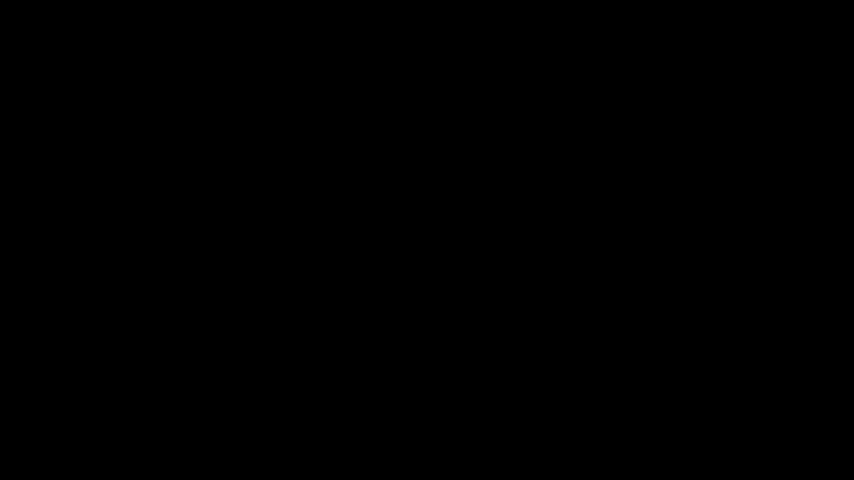

In [24]:

%%manim -v WARNING -ql -i TableToGraphAnimation
class TableToGraphAnimation(Scene):
    def construct(self):
        # --- Table data (x, y = x^2) ---
        data = [
            ["x", "y = x^2"],
            ["-2", "4"],
            ["-1", "1"],
            ["0", "0"],
            ["1", "1"],
            ["2", "4"]
        ]

        # --- Create Table (Left Side) ---
        table = Table(
            data,
            include_outer_lines=True,
            line_config={"color": WHITE},
            element_to_mobject=lambda e: MathTex(e)
        ).scale(0.8).to_edge(LEFT)

        # --- Create Axes (Right Side) ---
        axes = Axes(
            x_range=[-3, 3],
            y_range=[0, 5],
            x_length=5,
            y_length=4,
            axis_config={"color": GREY}
        ).to_edge(RIGHT)
        labels = axes.get_axis_labels("x", "y")

        # --- Prepare graph data ---
        xy_values = [(-2,4), (-1,1), (0,0), (1,1), (2,4)]
        parabola = axes.plot(lambda x: x**2, color=BLUE)

        # --- Animate setup ---
        self.play(Create(table))
        self.play(Create(axes), Write(labels))
        self.wait(0.5)

        # --- Animate each (x, y) flying from table to graph ---
        dots = []
        for i, (x, y) in enumerate(xy_values, start=1):
            # Get cell positions (table row index starts at 1 for header)
            x_cell = table.get_cell((i+1, 1))  # x value cell
            y_cell = table.get_cell((i+1, 2))  # y value cell

            # Create small floating MathTex to animate
            x_val = MathTex(str(x))
            y_val = MathTex(str(y))

            # Place these texts on top of the corresponding table cells
            x_val.move_to(x_cell.get_center())
            y_val.move_to(y_cell.get_center())

            # Create the dot position on the graph
            point = axes.coords_to_point(x, y)
            dot = Dot(point, color=YELLOW)

            # Animate x and y flying to the graph point
            self.play(
                x_val.animate.move_to(point + LEFT*0.3),
                y_val.animate.move_to(point + UP*0.3),
                run_time=1.5
            )

            # Fade out texts and reveal the dot
            self.play(
                FadeOut(x_val),
                FadeOut(y_val),
                FadeIn(dot, scale=1.2),
                run_time=0.5
            )

            dots.append(dot)
            self.wait(0.3)

        # --- Draw parabola through points ---
        self.play(Create(parabola), run_time=3)
        self.wait(2)


[10/12/25 22:00:46] WARNING  --save_as_gif is deprecated, please use --format=gif instead!           ]8;id=694597;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py\commands.py]8;;\:]8;id=745883;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py#50\50]8;;\

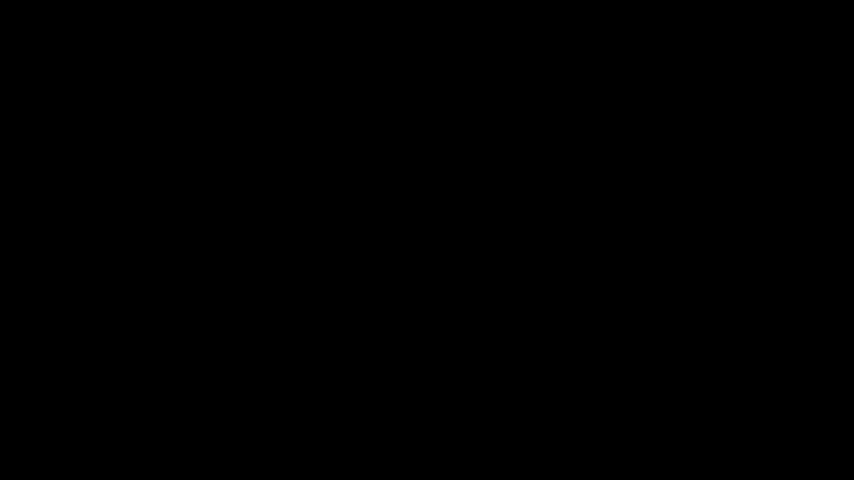

In [33]:
%%manim -v WARNING -ql -i CurveSketching_shifting
#Final portion of the graph of parabola through shifting 
class CurveSketching_shifting(Scene):

    def construct(self):

        # Divide the screen visually: left for text, right for graph
        left_text_area = Rectangle(width=5.5, height=7, color=GREY, fill_opacity=0).to_edge(LEFT)
        right_graph_area = Rectangle(width=5.5, height=7, color=GREY, fill_opacity=0).to_edge(RIGHT)
        # Uncomment next lines if you want to see the separation visually
        # self.add(left_text_area, right_graph_area)

        # Axes for y = x^2 graph (shifted to the right)
        axes = Axes(
            x_range=[-5, 5, 1],
            y_range=[-5, 5, 1],
            x_length=5,
            y_length=5,
            axis_config={"color": WHITE},
            tips=False
        ).to_edge(RIGHT).shift(LEFT * 0.5)

        # Math equatiions for origin test
        eqs = [
            "y = x^2 -4x +3",
            " \\Rightarrow y = (x-2)^2 - 1",
            "\\text{so the graph of $y = x^2 -4x +3$ } \\\\ \\text{is the graph of $y = x^2$ shifted} \\\\ \\text{right by 2 units and down by 1 unit}"
        ]

        m_eqs = [MathTex(e) for e in eqs]
        m_eqs[0].to_edge(UP).shift(LEFT * 2)
        for i, eq in enumerate(m_eqs):
            if i > 0:
                eq.next_to(m_eqs[i-1], DOWN, buff=0.6, aligned_edge=LEFT)
            self.play(Write(eq))
            self.wait(0.5)

[10/12/25 10:16:25] WARNING  --save_as_gif is deprecated, please use --format=gif instead!           ]8;id=96144;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py\commands.py]8;;\:]8;id=908537;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py#50\50]8;;\

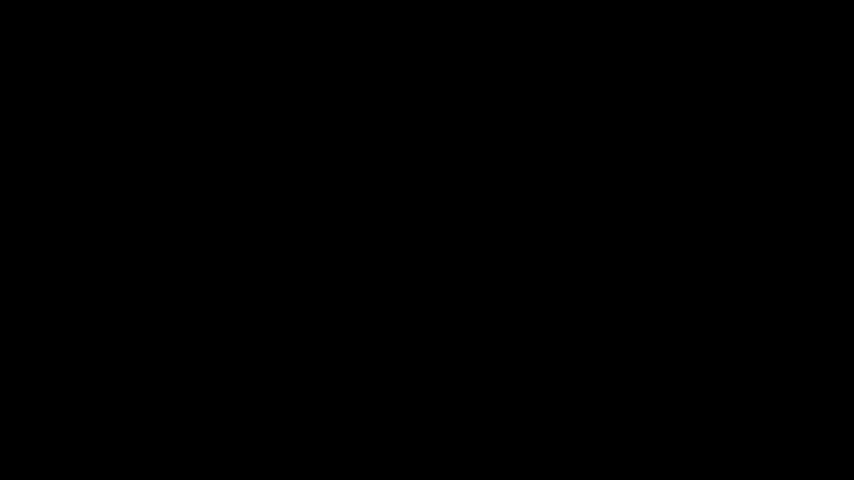

In [49]:
%%manim -v WARNING -ql -i MoveGraphKeepOriginal1

from manim import *

class MoveGraphKeepOriginal1(Scene):
    def construct(self):
        # Create axes
        axes = Axes(
            x_range=[-4, 4],
            y_range=[0, 8],
            axis_config={"color": GREY}
        )

        # Create the graph y = x^2
        parabola = axes.plot(lambda x: x**2, color=BLUE)
        label = axes.get_graph_label(parabola, label='y = x^2')

        self.play(Create(axes))
        self.play(Create(parabola), Write(label))
        self.wait(1)

        # Make a copy of the graph and move it
        parabola_copy = parabola.copy().set_color(BLUE)
        self.play(parabola_copy.animate.shift(RIGHT * 3 + DOWN * 2))

        # Change original parabola to grey
        self.play(parabola.animate.set_color(GREY))
        self.wait(1)

        # Fade out the copied parabola
        self.play(FadeOut(parabola_copy))
        self.wait(1)

[10/12/25 20:45:25] WARNING  --save_as_gif is deprecated, please use --format=gif instead!           ]8;id=207571;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py\commands.py]8;;\:]8;id=274265;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py#50\50]8;;\


(process:43807): GLib-GObject-WARNING **: 20:45:25.508: cannot unreference class of invalid (unclassed) type '(NULL)'


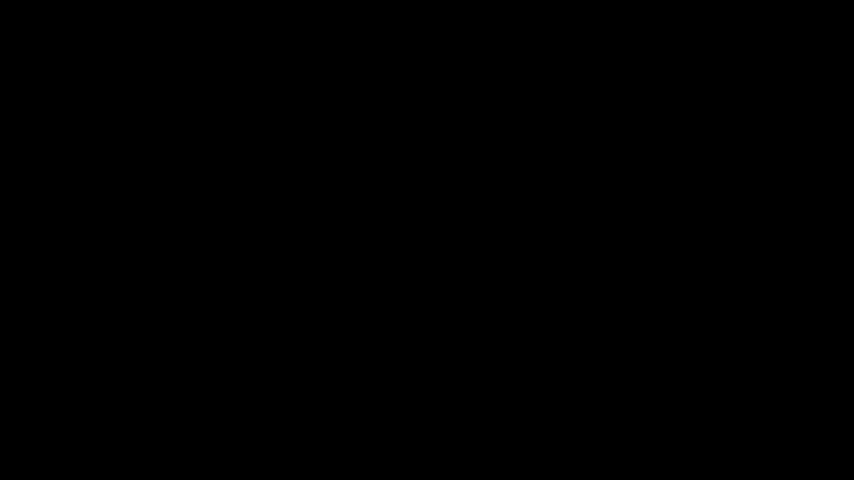

In [18]:
%%manim -v WARNING -ql -i NepaliText



class NepaliText(Scene):
    def construct(self):
        text = Text(
            "यो गणित धेरै रमाइलो छ!", 
            font="Devanagari Sangam MN"  # or "Mangal", "Kalimati", etc.
        )
        self.play(Write(text))
        self.wait(2)